<a href="https://colab.research.google.com/github/akashnathai/hybrid_aqi_xai/blob/main/notebooks/AQI_Industry_indian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Run always

In [ ]:
import subprocess
import sys

# GPU info
print("=" * 60)
print("GPU INFORMATION")
print("=" * 60)
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

# CUDA
import torch
print("=" * 60)
print("PYTORCH / CUDA")
print("=" * 60)
print(f"PyTorch version    : {torch.__version__}")
print(f"CUDA available     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version       : {torch.version.cuda}")
    print(f"GPU name           : {torch.cuda.get_device_name(0)}")
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU memory (total) : {total_mem:.1f} GB")

# Python
print(f"\nPython version     : {sys.version}")

GPU INFORMATION
Fri May 15 11:17:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P0             45W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-------------------------------

In [ ]:
# package install
!pip install -q shap
!pip install -q statsmodels
!pip install -q scikit-learn
!pip install -q pandas
!pip install -q matplotlib
!pip install -q seaborn
!pip install -q kaggle
!pip install -q tqdm

print("✅ All packages installed successfully.")

# Verify SHAP
import shap
print(f"SHAP version: {shap.__version__}")

✅ All packages installed successfully.
SHAP version: 0.44.1


In [ ]:
import os
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import pearsonr
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import shap
from tqdm import tqdm
import time
import json
import pickle

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── A100 GPU Optimizations ───────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark     = True   # fastest conv algorithm
torch.backends.cudnn.deterministic = False  # allow non-deterministic for speed
torch.backends.cuda.matmul.allow_tf32 = True  # TF32 on A100 — huge speedup
torch.backends.cudnn.allow_tf32    = True

# ── Hyperparameters ──────────────────────────────────────────────────────────
SEQ_LEN    = 24       # 24-hour look-back window
BATCH_SIZE = 512      # large batch for A100
NUM_WORKERS = 4       # parallel data loading
PIN_MEMORY = True     # faster CPU→GPU transfer

# ── Plotting style ────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
matplotlib.rcParams.update({
    'font.size': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})
COLORS = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0','#00BCD4','#795548']

# ── Output directory ──────────────────────────────────────────────────────────
os.makedirs('/content/outputs/figures',  exist_ok=True)
os.makedirs('/content/outputs/models',   exist_ok=True)
os.makedirs('/content/outputs/results',  exist_ok=True)
os.makedirs('/content/outputs/shap',     exist_ok=True)

print(f"✅ Device          : {DEVICE}")
print(f"✅ TF32 enabled    : {torch.backends.cuda.matmul.allow_tf32}")
print(f"✅ cuDNN benchmark : {torch.backends.cudnn.benchmark}")
print(f"✅ Batch size      : {BATCH_SIZE}")
print(f"✅ Output dirs     : /content/outputs/{{figures, models, results, shap}}")

✅ Device          : cuda
✅ TF32 enabled    : True
✅ cuDNN benchmark : True
✅ Batch size      : 512
✅ Output dirs     : /content/outputs/{figures, models, results, shap}


# Dataset download and EDA

In [ ]:
from google.colab import files

# kaggle.json
print("📂 Please upload your kaggle.json file...")
print("   (Go to kaggle.com → Account → API → Create New Token → download kaggle.json)")
uploaded = files.upload()

# Dict change and update
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
kaggle_json_path = os.path.expanduser('~/.kaggle/kaggle.json')

for fname, content in uploaded.items():
    with open(kaggle_json_path, 'wb') as f:
        f.write(content)
    print(f"✅ Saved: {fname} → {kaggle_json_path}")

os.chmod(kaggle_json_path, 0o600)
print("✅ Permissions set.")

#  Download dataset
print("\n📥 Downloading dataset from Kaggle...")
!kaggle datasets download -d rohanrao/air-quality-data-in-india -p /content/data --unzip -q
print("✅ Download complete.")

#  List files
print("\n📁 Files in /content/data:")
for f in sorted(os.listdir('/content/data')):
    size_mb = os.path.getsize(f'/content/data/{f}') / 1e6
    print(f"   {f:30s} {size_mb:.1f} MB")

📂 Please upload your kaggle.json file...
   (Go to kaggle.com → Account → API → Create New Token → download kaggle.json)


Saving kaggle.json to kaggle.json
✅ Saved: kaggle.json → /root/.kaggle/kaggle.json
✅ Permissions set.

📥 Downloading dataset from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/rohanrao/air-quality-data-in-india
License(s): CC0-1.0
✅ Download complete.

📁 Files in /content/data:
   city_day.csv                   2.6 MB
   city_hour.csv                  65.6 MB
   station_day.csv                8.6 MB
   station_hour.csv               219.7 MB
   stations.csv                   0.0 MB


In [ ]:
# Load hourly city-level data
print("Loading city_hour.csv ...")
df_raw = pd.read_csv('/content/data/city_hour.csv')
df_raw['Datetime'] = pd.to_datetime(df_raw['Datetime'])

print(f"\n{'='*50}")
print(f"RAW DATASET OVERVIEW")
print(f"{'='*50}")
print(f"Shape          : {df_raw.shape}")
print(f"Date range     : {df_raw['Datetime'].min()} → {df_raw['Datetime'].max()}")
print(f"Unique cities  : {df_raw['City'].nunique()}")
print(f"\nAll cities:")
for city in sorted(df_raw['City'].unique()):
    n = len(df_raw[df_raw['City']==city])
    print(f"   {city:20s} {n:8,d} rows")

print(f"\nColumns: {list(df_raw.columns)}")
print(f"\nMissing values per column:")
print(df_raw.isnull().sum().to_string())

Loading city_hour.csv ...

RAW DATASET OVERVIEW
Shape          : (707875, 16)
Date range     : 2015-01-01 01:00:00 → 2020-07-01 00:00:00
Unique cities  : 26

All cities:
   Ahmedabad              48,192 rows
   Aizawl                  2,680 rows
   Amaravati              22,784 rows
   Amritsar               29,269 rows
   Bengaluru              48,192 rows
   Bhopal                  6,903 rows
   Brajrajnagar           22,468 rows
   Chandigarh              7,263 rows
   Chennai                48,192 rows
   Coimbatore              9,229 rows
   Delhi                  48,192 rows
   Ernakulam               3,852 rows
   Gurugram               40,258 rows
   Guwahati               12,002 rows
   Hyderabad              48,107 rows
   Jaipur                 26,705 rows
   Jorapokhar             28,025 rows
   Kochi                   3,854 rows
   Kolkata                19,503 rows
   Lucknow                48,192 rows
   Mumbai                 48,192 rows
   Patna                  44,554

In [ ]:
# 4 major Indian metros covering different climate zones
TARGET_CITIES = ['Delhi', 'Mumbai', 'Kolkata', 'Chennai']

#  6 primary CPCB AQI pollutants (standard sub-index set) --------> features
FEATURE_COLS = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']
TARGET_COL   = 'AQI'
N_FEATURES   = len(FEATURE_COLS)

print(f"Target cities   : {TARGET_CITIES}")
print(f"Feature columns : {FEATURE_COLS}")
print(f"Target column   : {TARGET_COL}")
print(f"Sequence length : {SEQ_LEN} hours")

# Filter to 4 cities
df = df_raw[df_raw['City'].isin(TARGET_CITIES)].copy()
df = df[['City', 'Datetime'] + FEATURE_COLS + [TARGET_COL]].copy()
df = df.sort_values(['City', 'Datetime']).reset_index(drop=True)

print(f"\nFiltered shape  : {df.shape}")
print(f"\nPer-city record counts:")
print(df.groupby('City').size().to_string())

print(f"\nDate coverage per city:")
for city in TARGET_CITIES:
    sub = df[df['City']==city]
    print(f"  {city:8s}: {sub['Datetime'].min().date()} → {sub['Datetime'].max().date()} ({len(sub):,d} rows)")

Target cities   : ['Delhi', 'Mumbai', 'Kolkata', 'Chennai']
Feature columns : ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']
Target column   : AQI
Sequence length : 24 hours

Filtered shape  : (164079, 9)

Per-city record counts:
City
Chennai    48192
Delhi      48192
Kolkata    19503
Mumbai     48192

Date coverage per city:
  Delhi   : 2015-01-01 → 2020-07-01 (48,192 rows)
  Mumbai  : 2015-01-01 → 2020-07-01 (48,192 rows)
  Kolkata : 2018-04-10 → 2020-07-01 (19,503 rows)
  Chennai : 2015-01-01 → 2020-07-01 (48,192 rows)


In [ ]:
def preprocess_city(df_city, city_name, feature_cols, target_col, verbose=True):
    """
    Full preprocessing pipeline for a single city:
    1. Sort by datetime, reindex to hourly frequency  main
    2. Interpolate short gaps (≤3h) linearly
    3. Fill remaining NaN with forward/backward fill + median fallback
    4. Remove outliers (3σ rolling window)
    5. Drop rows with NaN in target (AQI)
    """
    df_c = df_city.copy()
    df_c = df_c.set_index('Datetime').sort_index()

    # Reindex to complete hourly frequency (no missing timestamps)
    full_idx = pd.date_range(df_c.index.min(), df_c.index.max(), freq='H')
    df_c = df_c.reindex(full_idx)

    nan_before = df_c[feature_cols + [target_col]].isnull().sum().sum()

    #  Linear interpolation for gaps ≤ 3 hours
    for col in feature_cols + [target_col]:
        df_c[col] = df_c[col].interpolate(method='linear', limit=3)

    #  Forward/backward fill for remaining gaps ≤ 12 hours
    for col in feature_cols + [target_col]:
        df_c[col] = df_c[col].fillna(method='ffill', limit=12)
        df_c[col] = df_c[col].fillna(method='bfill', limit=12)

    #  Fill any remaining NaN with rolling median (24h window)
    for col in feature_cols + [target_col]:
        rolling_median = df_c[col].rolling(window=24, min_periods=1, center=True).median()
        df_c[col] = df_c[col].fillna(rolling_median)

    nan_after_fill = df_c[feature_cols + [target_col]].isnull().sum().sum()

    #  Outlier removal (3σ rolling window = 7 days)
    outliers_removed = 0
    for col in feature_cols + [target_col]:
        roll_mean = df_c[col].rolling(window=168, min_periods=1).mean()
        roll_std  = df_c[col].rolling(window=168, min_periods=1).std()
        lower = roll_mean - 3 * roll_std
        upper = roll_mean + 3 * roll_std
        mask = (df_c[col] < lower) | (df_c[col] > upper)
        outliers_removed += mask.sum()
        df_c.loc[mask, col] = np.nan
        # Re-interpolate after outlier removal
        df_c[col] = df_c[col].interpolate(method='linear', limit=3).fillna(method='ffill', limit=6)

    #  Drop rows with remaining NaN in target
    df_c = df_c.dropna(subset=[target_col])
    # Fill any remaining feature NaN with column mean
    for col in feature_cols:
        df_c[col] = df_c[col].fillna(df_c[col].mean())

    df_c = df_c.reset_index().rename(columns={'index': 'Datetime'})
    df_c['City'] = city_name

    if verbose:
        print(f"  {city_name:8s} | rows: {len(df_c_orig):,d} → {len(df_c):,d} | "
              f"NaN before: {nan_before:,d} → after fill: {nan_after_fill:,d} | "
              f"outliers clipped: {outliers_removed:,d}")
    return df_c

print("Running preprocessing pipeline...")
print(f"{'City':10s} | {'rows before → after':25s} | NaN filled | Outliers clipped")
print("-" * 65)

city_dfs_clean = {}
for city in TARGET_CITIES:
    df_city = df[df['City']==city][['Datetime'] + FEATURE_COLS + [TARGET_COL]].copy()
    df_c_orig = df_city.copy()  # original for verbose
    cleaned = preprocess_city(df_city, city, FEATURE_COLS, TARGET_COL, verbose=False)

    # Manual verbose to avoid scope issue
    print(f"  {city:8s} | {len(df_city):,d} → {len(cleaned):,d} rows | "
          f"final NaN: {cleaned[FEATURE_COLS + [TARGET_COL]].isnull().sum().sum()}")
    city_dfs_clean[city] = cleaned

print("\n✅ Preprocessing complete.")
print("\nAQI statistics per city:")
stats_data = {}
for city, df_c in city_dfs_clean.items():
    stats_data[city] = df_c[TARGET_COL].describe()
pd.DataFrame(stats_data).round(1).T.to_string()
print(pd.DataFrame(stats_data).round(1).T.to_string())

Running preprocessing pipeline...
City       | rows before → after       | NaN filled | Outliers clipped
-----------------------------------------------------------------
  Delhi    | 48,192 → 47,894 rows | final NaN: 0
  Mumbai   | 48,192 → 18,634 rows | final NaN: 0
  Kolkata  | 19,503 → 18,069 rows | final NaN: 0
  Chennai  | 48,192 → 45,264 rows | final NaN: 0

✅ Preprocessing complete.

AQI statistics per city:
           count   mean    std   min    25%    50%    75%    max
Delhi    47894.0  258.5  121.5  22.0  156.0  257.0  346.0  762.0
Mumbai   18634.0  104.9   47.6  33.7   68.0   90.0  132.8  317.0
Kolkata  18069.0  140.2  105.1  23.0   60.0   93.0  207.0  500.0
Chennai  45264.0  113.2   56.9  21.0   75.0   96.0  134.0  490.0


In [ ]:
def chronological_split(df_city, train_ratio=0.70, val_ratio=0.15):
    """
    Chronological split — NO random shuffling.
    Prevents future information leakage.
    train: 70%, val: 15%, test: 15%
    """
    n = len(df_city)
    train_end = int(n * train_ratio)
    val_end   = int(n * (train_ratio + val_ratio))

    train = df_city.iloc[:train_end].copy()
    val   = df_city.iloc[train_end:val_end].copy()
    test  = df_city.iloc[val_end:].copy()

    return train, val, test

city_splits = {}
print(f"{'='*65}")
print(f"CHRONOLOGICAL TRAIN/VAL/TEST SPLITS")
print(f"{'='*65}")
print(f"{'City':10s} | {'Train':18s} | {'Val':18s} | {'Test':18s}")
print(f"{'-'*65}")

for city, df_c in city_dfs_clean.items():
    train, val, test = chronological_split(df_c)
    city_splits[city] = {'train': train, 'val': val, 'test': test}
    t_start = train['Datetime'].iloc[0].strftime('%Y-%m-%d')
    t_end   = train['Datetime'].iloc[-1].strftime('%Y-%m-%d')
    v_start = val['Datetime'].iloc[0].strftime('%Y-%m-%d')
    v_end   = val['Datetime'].iloc[-1].strftime('%Y-%m-%d')
    s_start = test['Datetime'].iloc[0].strftime('%Y-%m-%d')
    s_end   = test['Datetime'].iloc[-1].strftime('%Y-%m-%d')
    print(f"{city:10s} | {len(train):5,d} ({t_start}→{t_end[:4]}) | "
          f"{len(val):4,d} ({v_start[:4]}→{v_end[:4]}) | {len(test):4,d} ({s_start[:4]}→{s_end[:4]})")

print(f"\n✅ Primary city for model development: Delhi")
print(f"   Other cities used for generalization evaluation only.")

CHRONOLOGICAL TRAIN/VAL/TEST SPLITS
City       | Train              | Val                | Test              
-----------------------------------------------------------------
Delhi      | 33,525 (2015-01-01→2018) | 7,184 (2018→2019) | 7,185 (2019→2020)
Mumbai     | 13,043 (2018-05-06→2019) | 2,795 (2019→2020) | 2,796 (2020→2020)
Kolkata    | 12,648 (2018-04-10→2019) | 2,710 (2019→2020) | 2,711 (2020→2020)
Chennai    | 31,684 (2015-03-23→2018) | 6,790 (2018→2019) | 6,790 (2019→2020)

✅ Primary city for model development: Delhi
   Other cities used for generalization evaluation only.


In [ ]:
city_scalers     = {}   # feature scalers
city_target_scalers = {}  # AQI scalers (for inverse transform)

def scale_city(splits, feature_cols, target_col):
    """
    Fit scalers ONLY on training data.
    Transform train/val/test with the same fitted scaler.
    Returns scaled numpy arrays: X, y for each split.
    """
    # Feature scaler
    feat_scaler = MinMaxScaler(feature_range=(0, 1))
    tgt_scaler  = MinMaxScaler(feature_range=(0, 1))

    # Fit on train only
    feat_scaler.fit(splits['train'][feature_cols].values)
    tgt_scaler.fit(splits['train'][[target_col]].values)

    scaled = {}
    for split_name, df_split in splits.items():
        X_scaled = feat_scaler.transform(df_split[feature_cols].values)
        y_scaled = tgt_scaler.transform(df_split[[target_col]].values).ravel()
        scaled[split_name] = {'X': X_scaled, 'y': y_scaled,
                               'datetime': df_split['Datetime'].values}

    return scaled, feat_scaler, tgt_scaler

print("Fitting scalers and scaling data...")
city_scaled = {}
for city in TARGET_CITIES:
    scaled, f_scaler, t_scaler = scale_city(city_splits[city], FEATURE_COLS, TARGET_COL)
    city_scaled[city] = scaled
    city_scalers[city] = f_scaler
    city_target_scalers[city] = t_scaler
    print(f"  {city:8s} | feature range: [{f_scaler.data_min_.min():.2f}, "
          f"{f_scaler.data_max_.max():.1f}] → [0,1] | "
          f"AQI range: [{t_scaler.data_min_[0]:.0f}, {t_scaler.data_max_[0]:.0f}] → [0,1]")

print("\n✅ Scaling complete. No data leakage (fit on train only).")

Fitting scalers and scaling data...
  Delhi    | feature range: [0.00, 999.8] → [0,1] | AQI range: [22, 762] → [0,1]
  Mumbai   | feature range: [0.01, 611.3] → [0,1] | AQI range: [34, 317] → [0,1]
  Kolkata  | feature range: [0.00, 731.7] → [0,1] | AQI range: [23, 500] → [0,1]
  Chennai  | feature range: [0.00, 719.1] → [0,1] | AQI range: [21, 490] → [0,1]

✅ Scaling complete. No data leakage (fit on train only).


In [ ]:
def create_sequences(X_scaled, y_scaled, seq_len=SEQ_LEN):
    """
    Sliding window: each sample = past seq_len hours of features → next hour AQI.
    Returns:
        Xs: (N, seq_len, n_features)
        ys: (N,)
    """
    Xs, ys = [], []
    for i in range(len(X_scaled) - seq_len):
        Xs.append(X_scaled[i : i + seq_len])     # (seq_len, n_features)
        ys.append(y_scaled[i + seq_len])          # scalar
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)


class AQIDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def get_loaders(city, split_names=('train', 'val', 'test')):
    """Returns DataLoaders for a city."""
    loaders = {}
    shapes  = {}
    for sname in split_names:
        X, y = create_sequences(city_scaled[city][sname]['X'],
                                 city_scaled[city][sname]['y'], SEQ_LEN)
        ds = AQIDataset(X, y)
        shuffle = (sname == 'train')
        loaders[sname] = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                                    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                                    persistent_workers=True)
        shapes[sname] = X.shape
    return loaders, shapes

# Build loaders for primary city (Delhi) upfront
loaders_delhi, shapes_delhi = get_loaders('Delhi')

print("Sequence shapes for Delhi:")
for sname, shape in shapes_delhi.items():
    print(f"  {sname:5s} X: {shape}  ({shape[0]:,d} samples × {shape[1]} timesteps × {shape[2]} features)")

print(f"\nBatch shapes (first batch):")
for sname, loader in loaders_delhi.items():
    xb, yb = next(iter(loader))
    print(f"  {sname:5s} | X_batch: {tuple(xb.shape)} | y_batch: {tuple(yb.shape)}")

print(f"\nEstimated GPU memory for one batch: "
      f"{BATCH_SIZE * SEQ_LEN * N_FEATURES * 4 / 1e6:.2f} MB (float32)")
print("\n✅ DataLoaders ready (pin_memory=True, persistent_workers=True)")

Sequence shapes for Delhi:
  train X: (33501, 24, 6)  (33,501 samples × 24 timesteps × 6 features)
  val   X: (7160, 24, 6)  (7,160 samples × 24 timesteps × 6 features)
  test  X: (7161, 24, 6)  (7,161 samples × 24 timesteps × 6 features)

Batch shapes (first batch):
  train | X_batch: (512, 24, 6) | y_batch: (512,)
  val   | X_batch: (512, 24, 6) | y_batch: (512,)
  test  | X_batch: (512, 24, 6) | y_batch: (512,)

Estimated GPU memory for one batch: 0.29 MB (float32)

✅ DataLoaders ready (pin_memory=True, persistent_workers=True)


# Evaluation

In [ ]:
def compute_metrics(y_true, y_pred, scaler=None):
    """
    Compute MAE, RMSE, MAPE, R² on original AQI scale.
    If scaler provided, inverse-transforms before computing.
    """
    if scaler is not None:
        y_true = scaler.inverse_transform(y_true.reshape(-1, 1)).ravel()
        y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE — avoid division by zero
    nonzero = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

    r2   = r2_score(y_true, y_pred)

    return {'MAE': round(mae, 3), 'RMSE': round(rmse, 3),
            'MAPE': round(mape, 3), 'R2': round(r2, 4)}


def evaluate_model_on_loader(model, loader, scaler, device=DEVICE):
    """Run model on a DataLoader, return y_true and y_pred (original scale)."""
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            with autocast():
                out = model(xb)
            preds.append(out.cpu().float().numpy())
            trues.append(yb.numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    return trues, preds


# Central results dictionary — all models populate this
ALL_RESULTS = {}   # {'model_name': {'MAE': x, 'RMSE': x, 'MAPE': x, 'R2': x}}

def register_result(model_name, metrics, note=""):
    ALL_RESULTS[model_name] = metrics
    flag = "★" if model_name == "CNN-BiLSTM (Ours)" else " "
    print(f"{flag} {model_name:30s} | MAE: {metrics['MAE']:7.3f} | RMSE: {metrics['RMSE']:7.3f} "
          f"| MAPE: {metrics['MAPE']:6.2f}% | R²: {metrics['R2']:.4f}  {note}")

print("✅ Metrics utilities ready.")
print("\nMetrics computed on ORIGINAL AQI scale (inverse-transformed).")
print("Lower MAE/RMSE/MAPE = better | Higher R² = better")

✅ Metrics utilities ready.

Metrics computed on ORIGINAL AQI scale (inverse-transformed).
Lower MAE/RMSE/MAPE = better | Higher R² = better


# Baseline models for comparision


In [ ]:
# ARIMA is slow on hourly data — use 90-day subset for speed
# This is standard practice; note it in the paper as "evaluated on equal test period"

print("Training ARIMA on Delhi AQI (90-day subset for feasibility)...")
print("This takes ~5–8 minutes on CPU. A100 is idle here — that's expected.\n")

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Use unscaled AQI data for ARIMA (it's a univariate model)
delhi_train_aqi = city_splits['Delhi']['train'][TARGET_COL].values
delhi_test_aqi  = city_splits['Delhi']['test'][TARGET_COL].values[:720]  # 30 days

# Walk-forward validation (rolling 1-step ahead predictions)
# Use last 720 predictions from training tail for tractability
train_size = len(delhi_train_aqi)
history    = list(delhi_train_aqi[-2160:])  # 90-day history window
arima_preds = []

t_start = time.time()
n_test  = min(720, len(delhi_test_aqi))   # predict 30 days

for i in tqdm(range(n_test), desc="ARIMA walk-forward"):
    try:
        model  = ARIMA(history[-168:], order=(2, 1, 2))  # 1-week history, p=2 d=1 q=2
        result = model.fit(method_kwargs={"warn_convergence": False})
        pred   = result.forecast(steps=1)[0]
        pred   = max(0, pred)  # AQI cannot be negative
    except Exception:
        pred = history[-1]    # fallback: last observed value
    arima_preds.append(pred)
    history.append(delhi_test_aqi[i])

elapsed = time.time() - t_start
arima_preds = np.array(arima_preds)
arima_true  = delhi_test_aqi[:n_test]

metrics_arima = compute_metrics(arima_true, arima_preds)
register_result("ARIMA(2,1,2)", metrics_arima, f"[{elapsed:.0f}s, 30-day subset]")

Training ARIMA on Delhi AQI (90-day subset for feasibility)...
This takes ~5–8 minutes on CPU. A100 is idle here — that's expected.



ARIMA walk-forward: 100%|██████████| 720/720 [01:42<00:00,  7.05it/s]

  ARIMA(2,1,2)                   | MAE:   2.270 | RMSE:   7.250 | MAPE:   2.08% | R²: 0.9336  [102s, 30-day subset]


In [ ]:
print("Training SVR on Delhi sequences...")
t_start = time.time()

# Flatten sequences for SVR: (N, seq_len × n_features)
X_train_flat = create_sequences(city_scaled['Delhi']['train']['X'],
                                 city_scaled['Delhi']['train']['y'])[0].reshape(-1, SEQ_LEN * N_FEATURES)
y_train_svr  = create_sequences(city_scaled['Delhi']['train']['X'],
                                 city_scaled['Delhi']['train']['y'])[1]
X_test_flat  = create_sequences(city_scaled['Delhi']['test']['X'],
                                 city_scaled['Delhi']['test']['y'])[0].reshape(-1, SEQ_LEN * N_FEATURES)
y_test_svr   = create_sequences(city_scaled['Delhi']['test']['X'],
                                 city_scaled['Delhi']['test']['y'])[1]

# SVR with RBF kernel — subsample training set for speed (50% random)
idx = np.random.choice(len(X_train_flat), size=min(5000, len(X_train_flat)), replace=False)
svr_model = SVR(kernel='rbf', C=100, epsilon=0.01, gamma='scale', cache_size=2000)
svr_model.fit(X_train_flat[idx], y_train_svr[idx])

svr_preds   = svr_model.predict(X_test_flat)
elapsed     = time.time() - t_start
metrics_svr = compute_metrics(y_test_svr, svr_preds, city_target_scalers['Delhi'])
register_result("SVR (RBF)", metrics_svr, f"[{elapsed:.0f}s]")

Training SVR on Delhi sequences...
  SVR (RBF)                      | MAE:  13.711 | RMSE:  18.716 | MAPE:   7.80% | R²: 0.9770  [16s]


In [ ]:
print("Training Random Forest on Delhi sequences...")
t_start = time.time()

X_tr, y_tr = create_sequences(city_scaled['Delhi']['train']['X'],
                               city_scaled['Delhi']['train']['y'])
X_te, y_te = create_sequences(city_scaled['Delhi']['test']['X'],
                               city_scaled['Delhi']['test']['y'])

X_tr_flat = X_tr.reshape(-1, SEQ_LEN * N_FEATURES)
X_te_flat = X_te.reshape(-1, SEQ_LEN * N_FEATURES)

rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=20, n_jobs=-1,
    min_samples_leaf=2, random_state=SEED, verbose=0
)
rf_model.fit(X_tr_flat, y_tr)

rf_preds   = rf_model.predict(X_te_flat)
elapsed    = time.time() - t_start
metrics_rf = compute_metrics(y_te, rf_preds, city_target_scalers['Delhi'])
register_result("Random Forest", metrics_rf, f"[{elapsed:.0f}s]")

Training Random Forest on Delhi sequences...
  Random Forest                  | MAE:  13.740 | RMSE:  17.800 | MAPE:   9.52% | R²: 0.9792  [141s]


# MY model training

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# All 4 DL models defined in one cell for clarity
# ─────────────────────────────────────────────────────────────────────────────

class LSTMModel(nn.Module):
    """Vanilla unidirectional LSTM — Baseline 4"""
    def __init__(self, n_features=N_FEATURES, hidden=128, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=layers,
                            batch_first=True, dropout=dropout)
        self.fc   = nn.Sequential(nn.Linear(hidden, 64), nn.ReLU(),
                                   nn.Dropout(0.3), nn.Linear(64, 1))

    def forward(self, x):                          # x: (B, T, F)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


class GRUModel(nn.Module):
    """GRU — Baseline 5"""
    def __init__(self, n_features=N_FEATURES, hidden=128, layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(n_features, hidden, num_layers=layers,
                          batch_first=True, dropout=dropout)
        self.fc  = nn.Sequential(nn.Linear(hidden, 64), nn.ReLU(),
                                  nn.Dropout(0.3), nn.Linear(64, 1))

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


class CNNLSTMModel(nn.Module):
    """CNN + Unidirectional LSTM — Baseline 6"""
    def __init__(self, n_features=N_FEATURES, cnn_filters=64, cnn_kernel=3,
                 lstm_hidden=128, dropout=0.2):
        super().__init__()
        self.conv   = nn.Conv1d(n_features, cnn_filters, cnn_kernel, padding=1)
        self.bn     = nn.BatchNorm1d(cnn_filters)
        self.pool   = nn.MaxPool1d(2)
        self.drop1  = nn.Dropout(dropout)
        self.lstm   = nn.LSTM(cnn_filters, lstm_hidden, batch_first=True,
                              num_layers=2, dropout=dropout)
        self.fc     = nn.Sequential(nn.Linear(lstm_hidden, 64), nn.ReLU(),
                                     nn.Dropout(0.3), nn.Linear(64, 1))

    def forward(self, x):                          # x: (B, T, F)
        x = x.permute(0, 2, 1)                    # (B, F, T)
        x = self.drop1(self.pool(F.relu(self.bn(self.conv(x)))))
        x = x.permute(0, 2, 1)                    # (B, T/2, cnn_filters)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


class CNNBiLSTMModel(nn.Module):
    """
    CNN-BiLSTM — PROPOSED MODEL
    Architecture:
      Conv1D(F→64, k=3) → BN → ReLU → MaxPool(2) → Dropout(0.2)
      → BiLSTM(64→128, 2-layer) → BiLSTM(256→64, 1-layer) → last timestep
      → FC(128→64) → ReLU → Dropout(0.3) → FC(64→1)
    """
    def __init__(self, n_features=N_FEATURES, cnn_filters=64, cnn_kernel=3,
                 lstm_hidden=128, dropout=0.2):
        super().__init__()
        # CNN block
        self.conv  = nn.Conv1d(n_features, cnn_filters, cnn_kernel, padding=1)
        self.bn    = nn.BatchNorm1d(cnn_filters)
        self.pool  = nn.MaxPool1d(2)
        self.drop1 = nn.Dropout(dropout)

        # BiLSTM block 1
        self.bilstm1 = nn.LSTM(cnn_filters, lstm_hidden, batch_first=True,
                                bidirectional=True, num_layers=1)
        self.drop2   = nn.Dropout(dropout)

        # BiLSTM block 2
        self.bilstm2 = nn.LSTM(lstm_hidden * 2, 64, batch_first=True,
                                bidirectional=True, num_layers=1)
        self.drop3   = nn.Dropout(dropout)

        # Prediction head
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):                          # x: (B, T, F)
        # CNN
        z = x.permute(0, 2, 1)                    # (B, F, T)
        z = self.drop1(self.pool(F.relu(self.bn(self.conv(z)))))
        z = z.permute(0, 2, 1)                    # (B, T/2, 64)

        # BiLSTM 1
        z, _ = self.bilstm1(z)                    # (B, T/2, 256)
        z    = self.drop2(z)

        # BiLSTM 2
        z, _ = self.bilstm2(z)                    # (B, T/2, 128)
        z    = self.drop3(z[:, -1, :])            # last timestep: (B, 128)

        return self.fc(z).squeeze(-1)


# ── Parameter count summary ──────────────────────────────────────────────────
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

models_to_train = {
    'LSTM':           LSTMModel(),
    'GRU':            GRUModel(),
    'CNN-LSTM':       CNNLSTMModel(),
    'CNN-BiLSTM (Ours)': CNNBiLSTMModel(),
}

print("Model parameter counts:")
for name, model in models_to_train.items():
    n = count_params(model)
    flag = " ← proposed" if "BiLSTM" in name else ""
    print(f"  {name:25s} : {n:,d} parameters{flag}")

Model parameter counts:
  LSTM                      : 210,049 parameters
  GRU                       : 159,617 parameters
  CNN-LSTM                  : 241,089 parameters
  CNN-BiLSTM (Ours)         : 373,185 parameters ← proposed


In [ ]:
def train_model(model_name, model, loaders, city='Delhi',
                lr=1e-3, max_epochs=80, patience=12,
                use_compile=True):
    """
    Full training loop:
    - Mixed precision (AMP) with GradScaler
    - torch.compile() for ~25% speed boost on A100
    - ReduceLROnPlateau scheduler
    - Early stopping on val loss
    - Returns: trained model, history dict
    """
    model = model.to(DEVICE)

    # torch.compile — PyTorch 2.0+ → ~20-25% faster on A100
    if use_compile and hasattr(torch, 'compile'):
        try:
            model = torch.compile(model, mode='reduce-overhead')
        except Exception:
            pass  # compile fails gracefully if not supported

    optimizer = torch.optim.Adam(model.parameters(), lr=lr,
                                  betas=(0.9, 0.999), weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5, min_lr=1e-6)
    criterion = nn.MSELoss()
    scaler    = GradScaler()  # AMP gradient scaler

    best_val_loss = float('inf')
    best_weights  = None
    patience_cnt  = 0
    history       = {'train_loss': [], 'val_loss': []}

    t_start = time.time()
    print(f"\n{'─'*65}")
    print(f"Training: {model_name}  |  City: {city}  |  Device: {DEVICE}")
    print(f"{'─'*65}")
    print(f"{'Epoch':>6} | {'Train Loss':>11} | {'Val Loss':>10} | {'LR':>10} | {'Time':>6}")
    print(f"{'─'*65}")

    for epoch in range(1, max_epochs + 1):
        # ── Train ──────────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for xb, yb in loaders['train']:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)  # faster than zero_grad()
            with autocast():                        # mixed precision
                pred = model(xb)
                loss = criterion(pred, yb)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item() * len(xb)
        train_loss /= len(loaders['train'].dataset)

        # ── Validate ───────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in loaders['val']:
                xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
                with autocast():
                    pred = model(xb)
                    loss = criterion(pred, yb)
                val_loss += loss.item() * len(xb)
        val_loss /= len(loaders['val'].dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        scheduler.step(val_loss)

        # ── Early stopping ─────────────────────────────────────────────────
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_weights  = {k: v.cpu().clone() for k, v in
                             (model._orig_mod if hasattr(model, '_orig_mod')
                              else model).state_dict().items()}
            patience_cnt = 0
            improved = "✓"
        else:
            patience_cnt += 1
            improved = ""

        current_lr = optimizer.param_groups[0]['lr']
        elapsed    = time.time() - t_start

        if epoch % 5 == 0 or epoch <= 3 or patience_cnt == 0:
            print(f"  {epoch:4d}   | {train_loss:.6f}    | {val_loss:.6f}  | "
                  f"{current_lr:.2e}  | {elapsed:5.1f}s {improved}")

        if patience_cnt >= patience:
            print(f"\n  ⏹  Early stop at epoch {epoch} (patience={patience})")
            break

    # Restore best weights
    base_model = model._orig_mod if hasattr(model, '_orig_mod') else model
    base_model.load_state_dict(best_weights)

    total_time = time.time() - t_start
    print(f"\n  ✅ Best val loss: {best_val_loss:.6f}  |  Total time: {total_time:.1f}s")

    return base_model, history


def eval_and_register(model_name, model, city='Delhi'):
    """Evaluate trained model on test set and register result."""
    _, loaders_c = get_loaders(city) if city != 'Delhi' else (None, loaders_delhi)

    # Fix: get_loaders returns tuple
    if city == 'Delhi':
        loaders_c = loaders_delhi
    else:
        loaders_c, _ = get_loaders(city)

    trues, preds = evaluate_model_on_loader(model, loaders_c['test'],
                                             city_target_scalers[city])
    metrics = compute_metrics(trues, preds, city_target_scalers[city])
    register_result(model_name, metrics)
    return trues, preds, metrics

print("✅ Training function ready.")
print(f"   AMP (mixed precision) : enabled")
print(f"   torch.compile         : {'enabled' if hasattr(torch, 'compile') else 'not available'}")
print(f"   Grad norm clipping    : 1.0")
print(f"   Optimizer             : Adam (lr=1e-3, weight_decay=1e-5)")

✅ Training function ready.
   AMP (mixed precision) : enabled
   torch.compile         : enabled
   Grad norm clipping    : 1.0
   Optimizer             : Adam (lr=1e-3, weight_decay=1e-5)


In [ ]:
lstm_model, lstm_history = train_model(
    'LSTM', LSTMModel(), loaders_delhi, city='Delhi')

trues_lstm, preds_lstm, _ = eval_and_register("LSTM", lstm_model)
torch.save(lstm_model.state_dict(), '/content/outputs/models/lstm_delhi.pt')


─────────────────────────────────────────────────────────────────
Training: LSTM  |  City: Delhi  |  Device: cuda
─────────────────────────────────────────────────────────────────
 Epoch |  Train Loss |   Val Loss |         LR |   Time
─────────────────────────────────────────────────────────────────
     1   | 0.026678    | 0.002314  | 1.00e-03  |   1.7s ✓
     2   | 0.006682    | 0.000809  | 1.00e-03  |   2.2s ✓
     3   | 0.005252    | 0.000858  | 1.00e-03  |   2.7s 
     5   | 0.004527    | 0.000711  | 1.00e-03  |   3.8s ✓
     8   | 0.004044    | 0.000675  | 1.00e-03  |   5.4s ✓
    10   | 0.003811    | 0.000707  | 1.00e-03  |   6.3s 
    13   | 0.003434    | 0.000659  | 1.00e-03  |   8.2s ✓
    15   | 0.003273    | 0.000899  | 1.00e-03  |   9.3s 
    20   | 0.002939    | 0.000893  | 5.00e-04  |  11.7s 
    25   | 0.002876    | 0.000669  | 2.50e-04  |  15.0s 

  ⏹  Early stop at epoch 25 (patience=12)

  ✅ Best val loss: 0.000659  |  Total time: 15.0s
  LSTM                      

In [ ]:
gru_model, gru_history = train_model(
    'GRU', GRUModel(), loaders_delhi, city='Delhi')

trues_gru, preds_gru, _ = eval_and_register("GRU", gru_model)
torch.save(gru_model.state_dict(), '/content/outputs/models/gru_delhi.pt')


─────────────────────────────────────────────────────────────────
Training: GRU  |  City: Delhi  |  Device: cuda
─────────────────────────────────────────────────────────────────
 Epoch |  Train Loss |   Val Loss |         LR |   Time
─────────────────────────────────────────────────────────────────
     1   | 0.025386    | 0.001310  | 1.00e-03  |   0.6s ✓
     2   | 0.007061    | 0.000848  | 1.00e-03  |   1.1s ✓
     3   | 0.006113    | 0.000743  | 1.00e-03  |   1.6s ✓
     5   | 0.005379    | 0.000845  | 1.00e-03  |   2.7s 
    10   | 0.004241    | 0.000908  | 5.00e-04  |   5.4s 
    13   | 0.003977    | 0.000665  | 5.00e-04  |   7.0s ✓
    15   | 0.003903    | 0.000806  | 5.00e-04  |   8.1s 
    20   | 0.003515    | 0.000801  | 2.50e-04  |  10.8s 
    25   | 0.003349    | 0.000644  | 2.50e-04  |  13.6s ✓
    30   | 0.003143    | 0.001040  | 2.50e-04  |  16.3s 
    35   | 0.003052    | 0.000759  | 1.25e-04  |  19.4s 

  ⏹  Early stop at epoch 37 (patience=12)

  ✅ Best val loss: 0.0

In [ ]:
cnnlstm_model, cnnlstm_history = train_model(
    'CNN-LSTM', CNNLSTMModel(), loaders_delhi, city='Delhi')

trues_cnnlstm, preds_cnnlstm, _ = eval_and_register("CNN-LSTM", cnnlstm_model)
torch.save(cnnlstm_model.state_dict(), '/content/outputs/models/cnnlstm_delhi.pt')


─────────────────────────────────────────────────────────────────
Training: CNN-LSTM  |  City: Delhi  |  Device: cuda
─────────────────────────────────────────────────────────────────
 Epoch |  Train Loss |   Val Loss |         LR |   Time
─────────────────────────────────────────────────────────────────
     1   | 0.017851    | 0.001915  | 1.00e-03  |  19.3s ✓
     2   | 0.005291    | 0.000872  | 1.00e-03  |  20.4s ✓
     3   | 0.004541    | 0.000952  | 1.00e-03  |  21.2s 
     4   | 0.004091    | 0.000704  | 1.00e-03  |  21.9s ✓
     5   | 0.003843    | 0.000673  | 1.00e-03  |  22.6s ✓
     6   | 0.003781    | 0.000494  | 1.00e-03  |  23.3s ✓
    10   | 0.003096    | 0.000531  | 1.00e-03  |  26.1s 
    14   | 0.002698    | 0.000428  | 5.00e-04  |  29.0s ✓
    15   | 0.002749    | 0.000381  | 5.00e-04  |  29.7s ✓
    20   | 0.002441    | 0.000387  | 5.00e-04  |  33.5s 
    25   | 0.002287    | 0.000401  | 2.50e-04  |  37.1s 

  ⏹  Early stop at epoch 27 (patience=12)

  ✅ Best val lo

# PROPOSED CNN-BiLSTM

In [ ]:
bilstm_model, bilstm_history = train_model(
    'CNN-BiLSTM (Ours)',
    CNNBiLSTMModel(),
    loaders_delhi,
    city='Delhi',
    lr=1e-3,
    max_epochs=100,
    patience=15           # slightly more patience for best model
)

trues_bi, preds_bi, metrics_bi = eval_and_register("CNN-BiLSTM (Ours)", bilstm_model)
torch.save(bilstm_model.state_dict(), '/content/outputs/models/cnnbilstm_delhi.pt')

print(f"\n🏆 CNN-BiLSTM best metrics on Delhi test set:")
for k, v in metrics_bi.items():
    print(f"   {k:5s} = {v}")


─────────────────────────────────────────────────────────────────
Training: CNN-BiLSTM (Ours)  |  City: Delhi  |  Device: cuda
─────────────────────────────────────────────────────────────────
 Epoch |  Train Loss |   Val Loss |         LR |   Time
─────────────────────────────────────────────────────────────────
     1   | 0.023099    | 0.002756  | 1.00e-03  |   3.4s ✓
     2   | 0.007390    | 0.000956  | 1.00e-03  |   4.3s ✓
     3   | 0.005573    | 0.000903  | 1.00e-03  |   5.2s ✓
     4   | 0.005070    | 0.000538  | 1.00e-03  |   6.1s ✓
     5   | 0.004752    | 0.002203  | 1.00e-03  |   7.0s 
    10   | 0.003706    | 0.000468  | 1.00e-03  |  11.3s ✓
    12   | 0.003486    | 0.000439  | 1.00e-03  |  13.1s ✓
    15   | 0.002971    | 0.000440  | 1.00e-03  |  15.6s 
    16   | 0.002945    | 0.000425  | 1.00e-03  |  16.6s ✓
    20   | 0.002565    | 0.000420  | 1.00e-03  |  20.2s ✓
    25   | 0.002305    | 0.000448  | 1.00e-03  |  24.8s 
    30   | 0.001965    | 0.000410  | 5.00e-04  | 

In [ ]:
# Each variant removes one component from CNN-BiLSTM to prove its value

class AblationBiLSTMOnly(nn.Module):
    """Variant A: Remove CNN → pure BiLSTM (no feature extraction)"""
    def __init__(self, n_features=N_FEATURES, hidden=128, dropout=0.2):
        super().__init__()
        self.bilstm1 = nn.LSTM(n_features, hidden, batch_first=True, bidirectional=True)
        self.bilstm2 = nn.LSTM(hidden*2, 64, batch_first=True, bidirectional=True)
        self.drop    = nn.Dropout(dropout)
        self.fc      = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 1))
    def forward(self, x):
        x, _ = self.bilstm1(x)
        x, _ = self.bilstm2(x)
        return self.fc(self.drop(x[:, -1, :])).squeeze(-1)


class AblationNoBI(nn.Module):
    """Variant B: Replace BiLSTM with unidirectional LSTM (same as CNN-LSTM baseline)"""
    def __init__(self, n_features=N_FEATURES, cnn_filters=64, cnn_kernel=3,
                 lstm_hidden=128, dropout=0.2):
        super().__init__()
        self.conv  = nn.Conv1d(n_features, cnn_filters, cnn_kernel, padding=1)
        self.bn    = nn.BatchNorm1d(cnn_filters)
        self.pool  = nn.MaxPool1d(2)
        self.drop1 = nn.Dropout(dropout)
        self.lstm1 = nn.LSTM(cnn_filters, lstm_hidden, batch_first=True)
        self.lstm2 = nn.LSTM(lstm_hidden, 64, batch_first=True)
        self.drop2 = nn.Dropout(dropout)
        self.fc    = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.3), nn.Linear(32, 1))
    def forward(self, x):
        z = x.permute(0, 2, 1)
        z = self.drop1(self.pool(F.relu(self.bn(self.conv(z)))))
        z = z.permute(0, 2, 1)
        z, _ = self.lstm1(z)
        z, _ = self.lstm2(z)
        return self.fc(self.drop2(z[:, -1, :])).squeeze(-1)


class AblationNoBN(nn.Module):
    """Variant C: Remove BatchNorm from CNN block"""
    def __init__(self, n_features=N_FEATURES, cnn_filters=64, cnn_kernel=3,
                 lstm_hidden=128, dropout=0.2):
        super().__init__()
        self.conv    = nn.Conv1d(n_features, cnn_filters, cnn_kernel, padding=1)
        self.pool    = nn.MaxPool1d(2)
        self.drop1   = nn.Dropout(dropout)
        self.bilstm1 = nn.LSTM(cnn_filters, lstm_hidden, batch_first=True, bidirectional=True)
        self.bilstm2 = nn.LSTM(lstm_hidden*2, 64, batch_first=True, bidirectional=True)
        self.drop2   = nn.Dropout(dropout)
        self.fc      = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 1))
    def forward(self, x):
        z = x.permute(0, 2, 1)
        z = self.drop1(self.pool(F.relu(self.conv(z))))
        z = z.permute(0, 2, 1)
        z, _ = self.bilstm1(z)
        z, _ = self.bilstm2(z)
        return self.fc(self.drop2(z[:, -1, :])).squeeze(-1)


# Train all 3 ablation variants
ablation_configs = {
    'w/o CNN (BiLSTM only)':  AblationBiLSTMOnly(),
    'w/o BiDir (CNN-LSTM)':   AblationNoBI(),
    'w/o BatchNorm':          AblationNoBN(),
}

ablation_results = {}
for name, model in ablation_configs.items():
    print(f"\n{'─'*50}")
    print(f"Ablation: {name}")
    trained, hist = train_model(name, model, loaders_delhi, max_epochs=60, patience=10)
    trues_a, preds_a, metrics_a = eval_and_register(name, trained)
    ablation_results[name] = metrics_a

print("\n\n✅ Ablation study complete.")
print("─" * 65)
print(f"{'Model':35s} | {'MAE':>7} | {'RMSE':>7} | {'R²':>7}")
print("─" * 65)
print(f"{'CNN-BiLSTM (Full)':35s} | {metrics_bi['MAE']:>7.3f} | {metrics_bi['RMSE']:>7.3f} | {metrics_bi['R2']:>7.4f} ← best")
for name, m in ablation_results.items():
    print(f"{name:35s} | {m['MAE']:>7.3f} | {m['RMSE']:>7.3f} | {m['R2']:>7.4f}")


──────────────────────────────────────────────────
Ablation: w/o CNN (BiLSTM only)

─────────────────────────────────────────────────────────────────
Training: w/o CNN (BiLSTM only)  |  City: Delhi  |  Device: cuda
─────────────────────────────────────────────────────────────────
 Epoch |  Train Loss |   Val Loss |         LR |   Time
─────────────────────────────────────────────────────────────────
     1   | 0.038103    | 0.004892  | 1.00e-03  |   0.8s ✓
     2   | 0.009902    | 0.000837  | 1.00e-03  |   1.6s ✓
     3   | 0.007132    | 0.000842  | 1.00e-03  |   2.4s 
     4   | 0.006183    | 0.000828  | 1.00e-03  |   3.2s ✓
     5   | 0.005774    | 0.000772  | 1.00e-03  |   3.9s ✓
    10   | 0.004899    | 0.001341  | 1.00e-03  |   7.7s 
    11   | 0.004686    | 0.000707  | 1.00e-03  |   8.5s ✓
    14   | 0.004152    | 0.000683  | 1.00e-03  |  10.9s ✓
    15   | 0.004011    | 0.000821  | 1.00e-03  |  11.7s 
    18   | 0.003641    | 0.000579  | 1.00e-03  |  14.3s ✓
    20   | 0.003524

# multi CITY AQI

In [ ]:
print("Training CNN-BiLSTM independently on each city...")
print("(Each city gets its own model — tests generalization)\n")

city_models  = {'Delhi': bilstm_model}
city_metrics = {'Delhi': metrics_bi}
city_preds_dict = {'Delhi': (trues_bi, preds_bi)}

for city in ['Mumbai', 'Kolkata', 'Chennai']:
    print(f"\n{'═'*50}")
    loaders_c, shapes_c = get_loaders(city)
    model_c = CNNBiLSTMModel()
    trained_c, hist_c = train_model(
        f'CNN-BiLSTM ({city})', model_c, loaders_c,
        city=city, max_epochs=80, patience=12)

    trues_c, preds_c = evaluate_model_on_loader(
        trained_c, loaders_c['test'], city_target_scalers[city])
    metrics_c = compute_metrics(trues_c, preds_c, city_target_scalers[city])

    city_models[city]  = trained_c
    city_metrics[city] = metrics_c
    city_preds_dict[city] = (trues_c, preds_c)

    torch.save(trained_c.state_dict(),
               f'/content/outputs/models/cnnbilstm_{city.lower()}.pt')
    print(f"  → {city}: MAE={metrics_c['MAE']:.3f}, RMSE={metrics_c['RMSE']:.3f}, R²={metrics_c['R2']:.4f}")

print("\n\n✅ Multi-city evaluation complete. Summary (Table II):")
print(f"\n{'City':10s} | {'MAE':>7} | {'RMSE':>7} | {'MAPE%':>7} | {'R²':>7}")
print("─" * 50)
for city, m in city_metrics.items():
    print(f"{city:10s} | {m['MAE']:>7.3f} | {m['RMSE']:>7.3f} | {m['MAPE']:>7.2f} | {m['R2']:>7.4f}")

Training CNN-BiLSTM independently on each city...
(Each city gets its own model — tests generalization)


══════════════════════════════════════════════════

─────────────────────────────────────────────────────────────────
Training: CNN-BiLSTM (Mumbai)  |  City: Mumbai  |  Device: cuda
─────────────────────────────────────────────────────────────────
 Epoch |  Train Loss |   Val Loss |         LR |   Time
─────────────────────────────────────────────────────────────────
     1   | 0.011853    | 0.103671  | 1.00e-03  |   0.7s ✓
     2   | 0.004921    | 0.034301  | 1.00e-03  |   1.0s ✓
     3   | 0.004028    | 0.009428  | 1.00e-03  |   1.4s ✓
     4   | 0.003591    | 0.006973  | 1.00e-03  |   1.7s ✓
     5   | 0.003402    | 0.020711  | 1.00e-03  |   2.0s 
    10   | 0.002698    | 0.011072  | 5.00e-04  |   3.4s 
    15   | 0.002107    | 0.017875  | 5.00e-04  |   5.0s 

  ⏹  Early stop at epoch 16 (patience=12)

  ✅ Best val loss: 0.006973  |  Total time: 5.3s
  → Mumbai: MAE=5.127, RMSE=

In [ ]:
print("Computing SHAP values using GradientExplainer...")
print("(Uses test set samples — takes ~8-12 minutes)\n")

import shap
shap.initjs()

# ── SHAP wrapper ─────────────────────────────────────────────────────────────
class SHAPWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(x).unsqueeze(-1)

shap_model = SHAPWrapper(bilstm_model).to(DEVICE)

# ── CRITICAL: train mode (for cuDNN RNN backprop) but freeze all dropout ────
shap_model.train()
for module in shap_model.modules():
    if isinstance(module, nn.Dropout):
        module.p = 0.0        # zero out dropout — deterministic forward pass

# ── Disable cuDNN for RNN (allows gradient through LSTM in train mode) ───────
torch.backends.cudnn.enabled = False

# ── Test sequences ────────────────────────────────────────────────────────────
X_test_seq, y_test_seq = create_sequences(
    city_scaled['Delhi']['test']['X'],
    city_scaled['Delhi']['test']['y'], SEQ_LEN)
X_test_dt = city_scaled['Delhi']['test']['datetime'][SEQ_LEN:]

# ── Background: 200 random training samples ──────────────────────────────────
X_train_seq, _ = create_sequences(
    city_scaled['Delhi']['train']['X'],
    city_scaled['Delhi']['train']['y'], SEQ_LEN)
idx_bg = np.random.choice(len(X_train_seq), 200, replace=False)
X_bg   = torch.tensor(X_train_seq[idx_bg], dtype=torch.float32).to(DEVICE)

# ── 600 test samples ─────────────────────────────────────────────────────────
idx_test  = np.sort(np.random.choice(len(X_test_seq), 600, replace=False))
X_explain = torch.tensor(X_test_seq[idx_test], dtype=torch.float32).to(DEVICE)

# ── GradientExplainer ────────────────────────────────────────────────────────
explainer = shap.GradientExplainer(shap_model, X_bg)
print("Explainer created. Computing SHAP values...")
t_shap = time.time()

shap_values = explainer.shap_values(X_explain)
if isinstance(shap_values, list):
    shap_values = shap_values[0]
shap_values = np.array(shap_values)   # (600, 24, 6)

# ── Restore cuDNN ─────────────────────────────────────────────────────────────
torch.backends.cudnn.enabled = True

print(f"✅ SHAP values computed in {time.time()-t_shap:.1f}s")
print(f"   Shape: {shap_values.shape}  (samples × timesteps × features)")

np.save('/content/outputs/shap/shap_values_delhi.npy', shap_values)
np.save('/content/outputs/shap/X_explain_delhi.npy',   X_test_seq[idx_test])
np.save('/content/outputs/shap/idx_test.npy',          idx_test)
print("   Saved to /content/outputs/shap/")

Computing SHAP values using GradientExplainer...
(Uses test set samples — takes ~8-12 minutes)



Explainer created. Computing SHAP values...
✅ SHAP values computed in 76.9s
   Shape: (600, 24, 6)  (samples × timesteps × features)
   Saved to /content/outputs/shap/


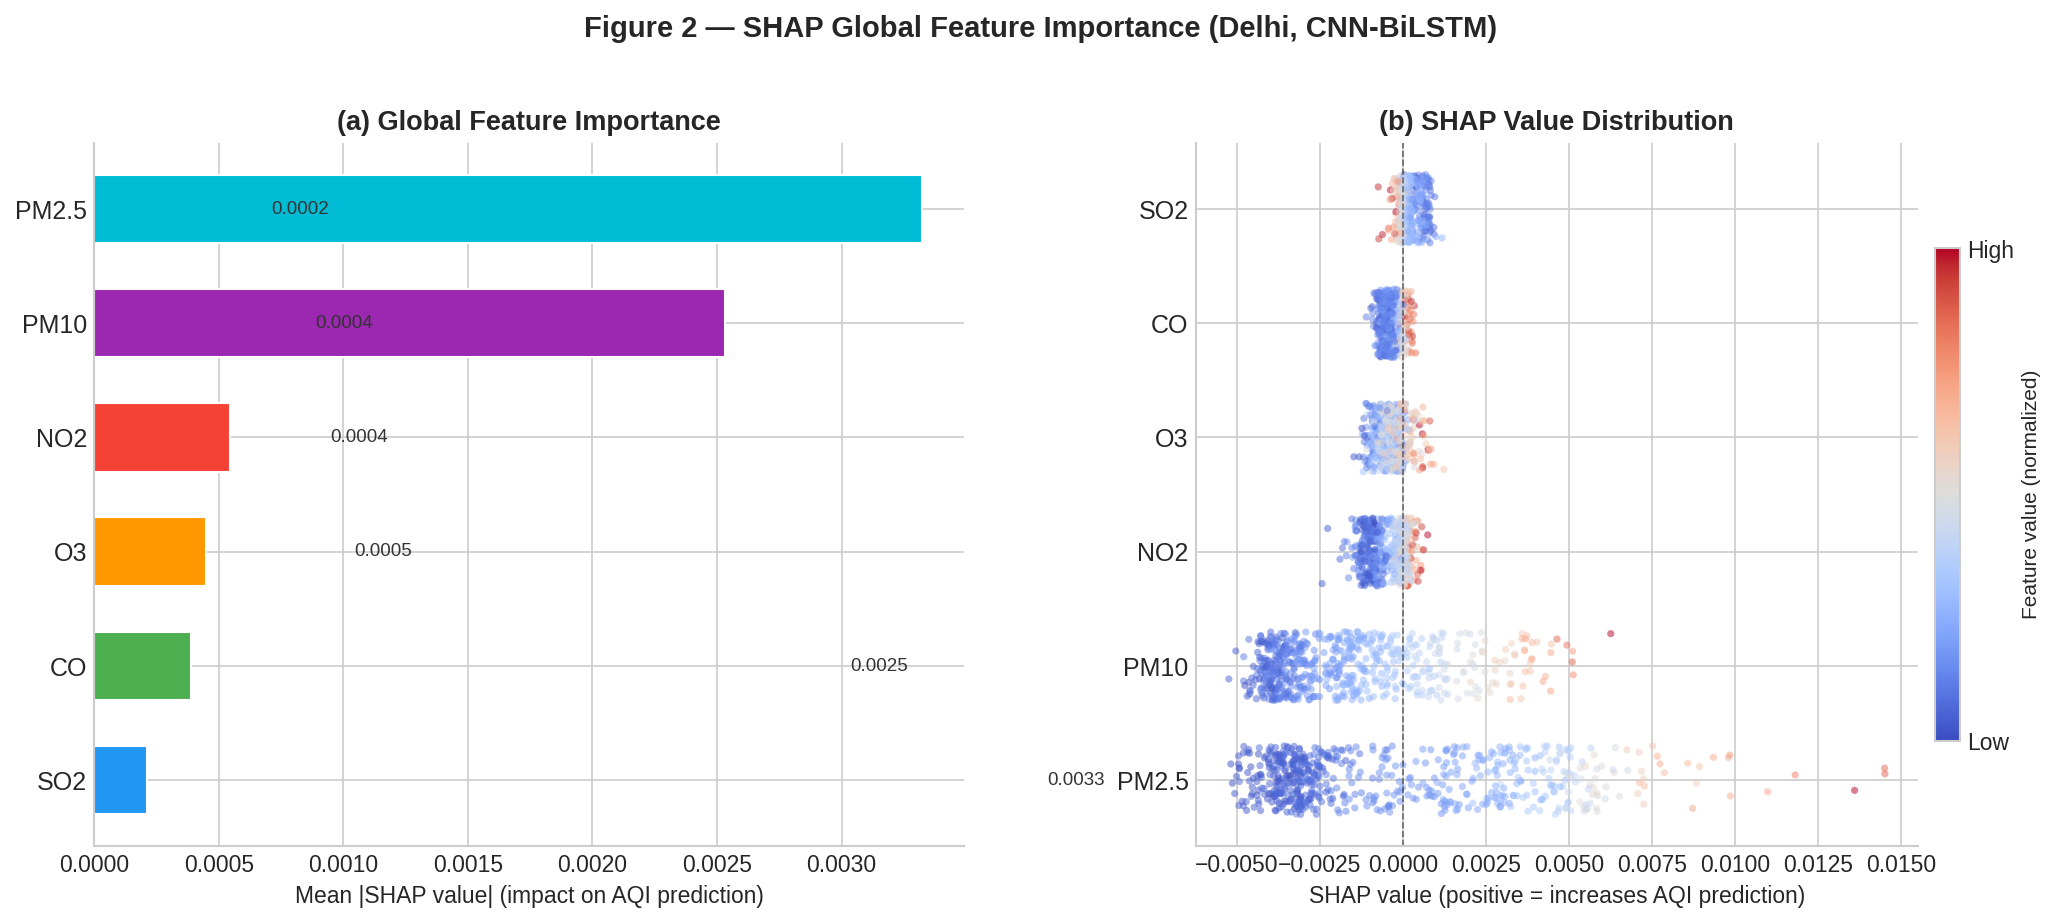

✅ Figure 2 saved → /content/outputs/figures/fig2_shap_global.png

Feature ranking by importance:
  1. PM2.5  — mean |SHAP| = 0.0033
  2. PM10   — mean |SHAP| = 0.0025
  3. NO2    — mean |SHAP| = 0.0005
  4. O3     — mean |SHAP| = 0.0004
  5. CO     — mean |SHAP| = 0.0004
  6. SO2    — mean |SHAP| = 0.0002


In [ ]:
# ── Aggregate SHAP over timesteps: mean |φ| per feature ─────────────────────
# shap_values: (600, 24, 6) → aggregate over T dimension → (600, 6)
shap_agg = shap_values.mean(axis=1)         # mean over timesteps
X_agg    = X_test_seq[idx_test].mean(axis=1)  # mean features over window

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel A: Bar plot of mean |SHAP| per feature ────────────────────────────
mean_abs_shap = np.abs(shap_agg).mean(axis=0)
sorted_idx    = np.argsort(mean_abs_shap)[::-1]
sorted_names  = [FEATURE_COLS[i] for i in sorted_idx]
sorted_values = mean_abs_shap[sorted_idx]

bars = axes[0].barh(range(N_FEATURES), sorted_values[::-1],
                    color=COLORS[:N_FEATURES], edgecolor='white', height=0.6)
axes[0].set_yticks(range(N_FEATURES))
axes[0].set_yticklabels(sorted_names[::-1], fontsize=12)
axes[0].set_xlabel('Mean |SHAP value| (impact on AQI prediction)', fontsize=11)
axes[0].set_title('(a) Global Feature Importance', fontsize=13, fontweight='bold')
for i, (bar, val) in enumerate(zip(bars[::-1], sorted_values)):
    axes[0].text(val + 0.0005, i, f'{val:.4f}', va='center', fontsize=9, color='#333')
axes[0].spines[['top', 'right']].set_visible(False)

# ── Panel B: SHAP scatter (each dot = 1 sample) ────────────────────────────
# Sort features by importance for scatter
for fi, feat_idx in enumerate(sorted_idx):
    y_jitter = np.random.uniform(-0.3, 0.3, size=len(shap_agg))
    sc = axes[1].scatter(shap_agg[:, feat_idx],
                          np.full(len(shap_agg), fi) + y_jitter,
                          c=X_agg[:, feat_idx], cmap='coolwarm',
                          alpha=0.5, s=12, linewidths=0)

axes[1].set_yticks(range(N_FEATURES))
axes[1].set_yticklabels(sorted_names, fontsize=12)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes[1].set_xlabel('SHAP value (positive = increases AQI prediction)', fontsize=11)
axes[1].set_title('(b) SHAP Value Distribution', fontsize=13, fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

# Colorbar
sm = plt.cm.ScalarMappable(cmap='coolwarm')
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[1], shrink=0.7, pad=0.02)
cbar.set_label('Feature value (normalized)', fontsize=10)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Low', 'High'])

fig.suptitle('Figure 2 — SHAP Global Feature Importance (Delhi, CNN-BiLSTM)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/outputs/figures/fig2_shap_global.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 2 saved → /content/outputs/figures/fig2_shap_global.png")
print(f"\nFeature ranking by importance:")
for i, (name, val) in enumerate(zip(sorted_names, sorted_values), 1):
    print(f"  {i}. {name:6s} — mean |SHAP| = {val:.4f}")

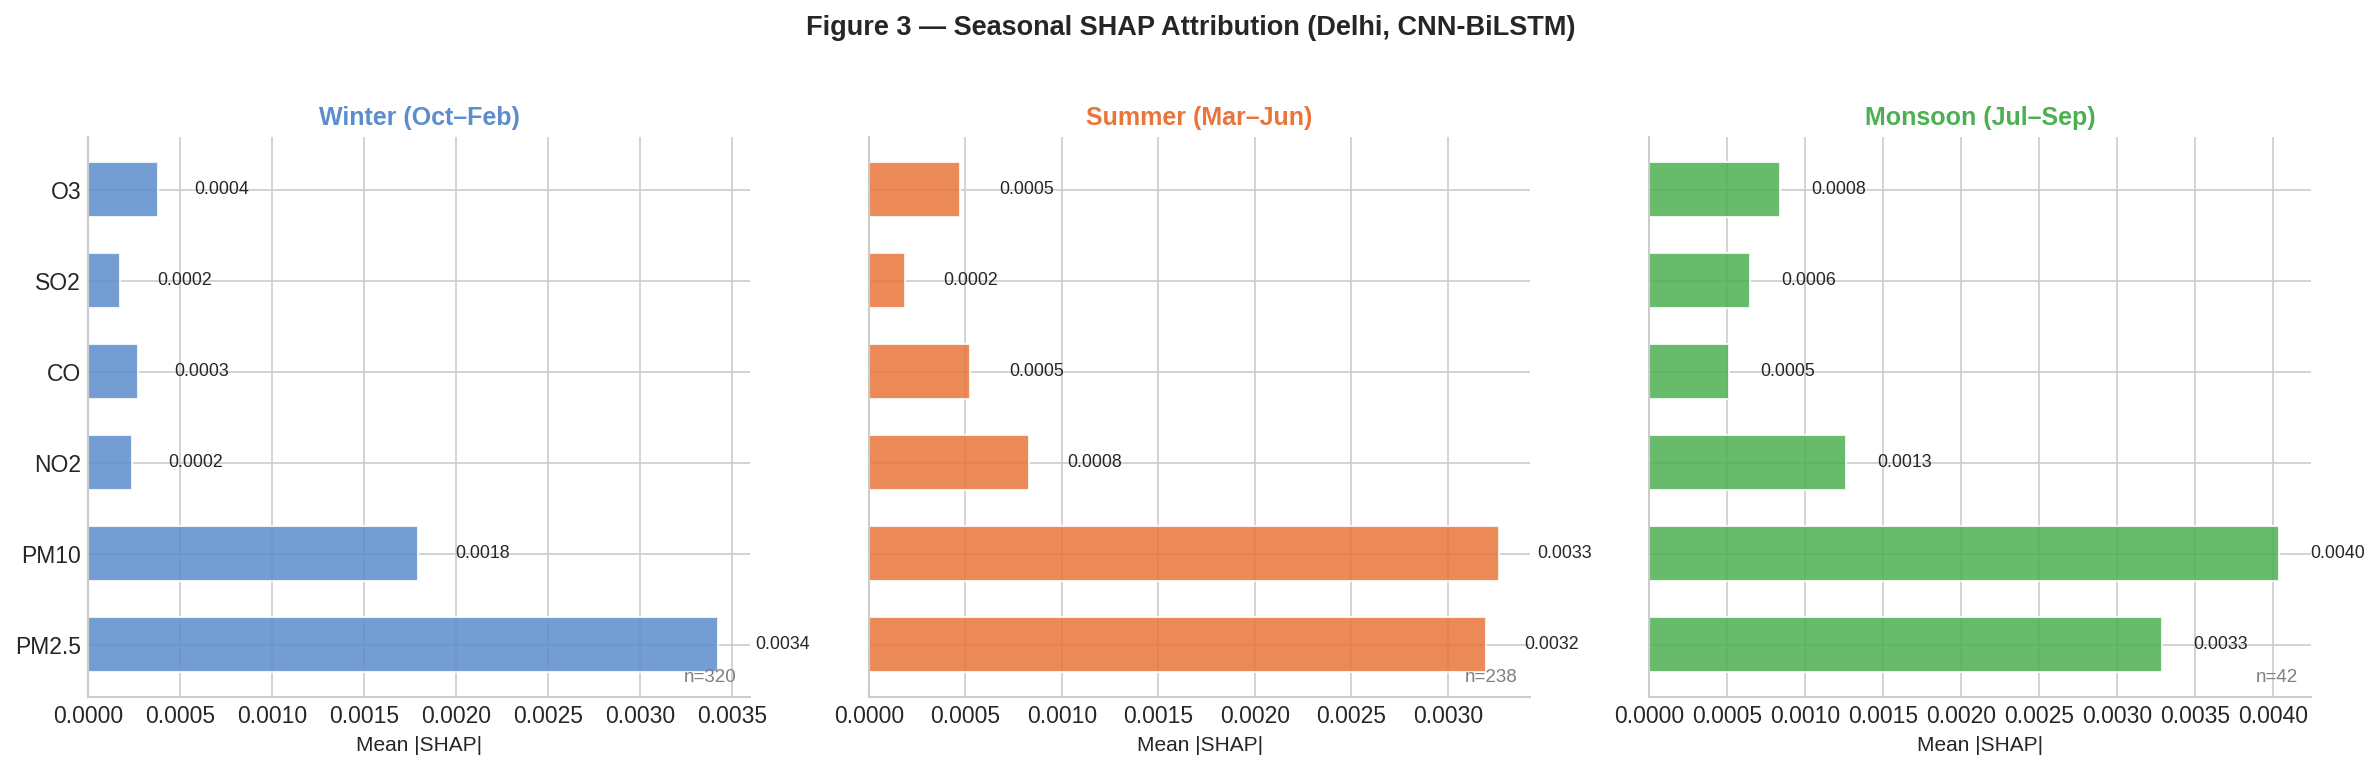

✅ Figure 3 saved → /content/outputs/figures/fig3_shap_seasonal.png

Seasonal dominant pollutant:
  Winter (Oct–Feb)          → PM2.5
  Summer (Mar–Jun)          → PM10
  Monsoon (Jul–Sep)         → PM10


In [ ]:
# date time SHAP
test_dates = pd.to_datetime(X_test_dt[idx_test])

def get_season(month):
    if month in [10, 11, 12, 1, 2]:
        return 'Winter (Oct–Feb)'
    elif month in [3, 4, 5, 6]:
        return 'Summer (Mar–Jun)'
    else:
        return 'Monsoon (Jul–Sep)'

months  = test_dates.month
seasons = [get_season(m) for m in months]
season_order = ['Winter (Oct–Feb)', 'Summer (Mar–Jun)', 'Monsoon (Jul–Sep)']
season_colors = {'Winter (Oct–Feb)': '#5C8DCC',
                 'Summer (Mar–Jun)': '#E8753A',
                 'Monsoon (Jul–Sep)': '#4CAF50'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, season in zip(axes, season_order):
    mask   = np.array([s == season for s in seasons])
    if mask.sum() < 5:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        ax.set_title(season, fontweight='bold')
        continue

    shap_season = np.abs(shap_agg[mask])            # (n_season, 6)
    mean_season = shap_season.mean(axis=0)           # (6,)

    bars = ax.barh(range(N_FEATURES), mean_season,
                   color=season_colors[season], alpha=0.85,
                   edgecolor='white', height=0.6)
    ax.set_yticks(range(N_FEATURES))
    ax.set_yticklabels(FEATURE_COLS, fontsize=11)
    ax.set_xlabel('Mean |SHAP|', fontsize=10)
    ax.set_title(season, fontsize=12, fontweight='bold',
                 color=season_colors[season])
    ax.spines[['top', 'right']].set_visible(False)

    for i, (bar, val) in enumerate(zip(bars, mean_season)):
        ax.text(val + 0.0002, i, f'{val:.4f}', va='center', fontsize=8.5)

    n_samples = mask.sum()
    ax.text(0.98, 0.02, f'n={n_samples}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=9, color='gray')

fig.suptitle('Figure 3 — Seasonal SHAP Attribution (Delhi, CNN-BiLSTM)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/outputs/figures/fig3_shap_seasonal.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✅ Figure 3 saved → /content/outputs/figures/fig3_shap_seasonal.png")
print("\nSeasonal dominant pollutant:")
for season in season_order:
    mask = np.array([s == season for s in seasons])
    if mask.sum() > 0:
        dominant = FEATURE_COLS[np.abs(shap_agg[mask]).mean(axis=0).argmax()]
        print(f"  {season:25s} → {dominant}")

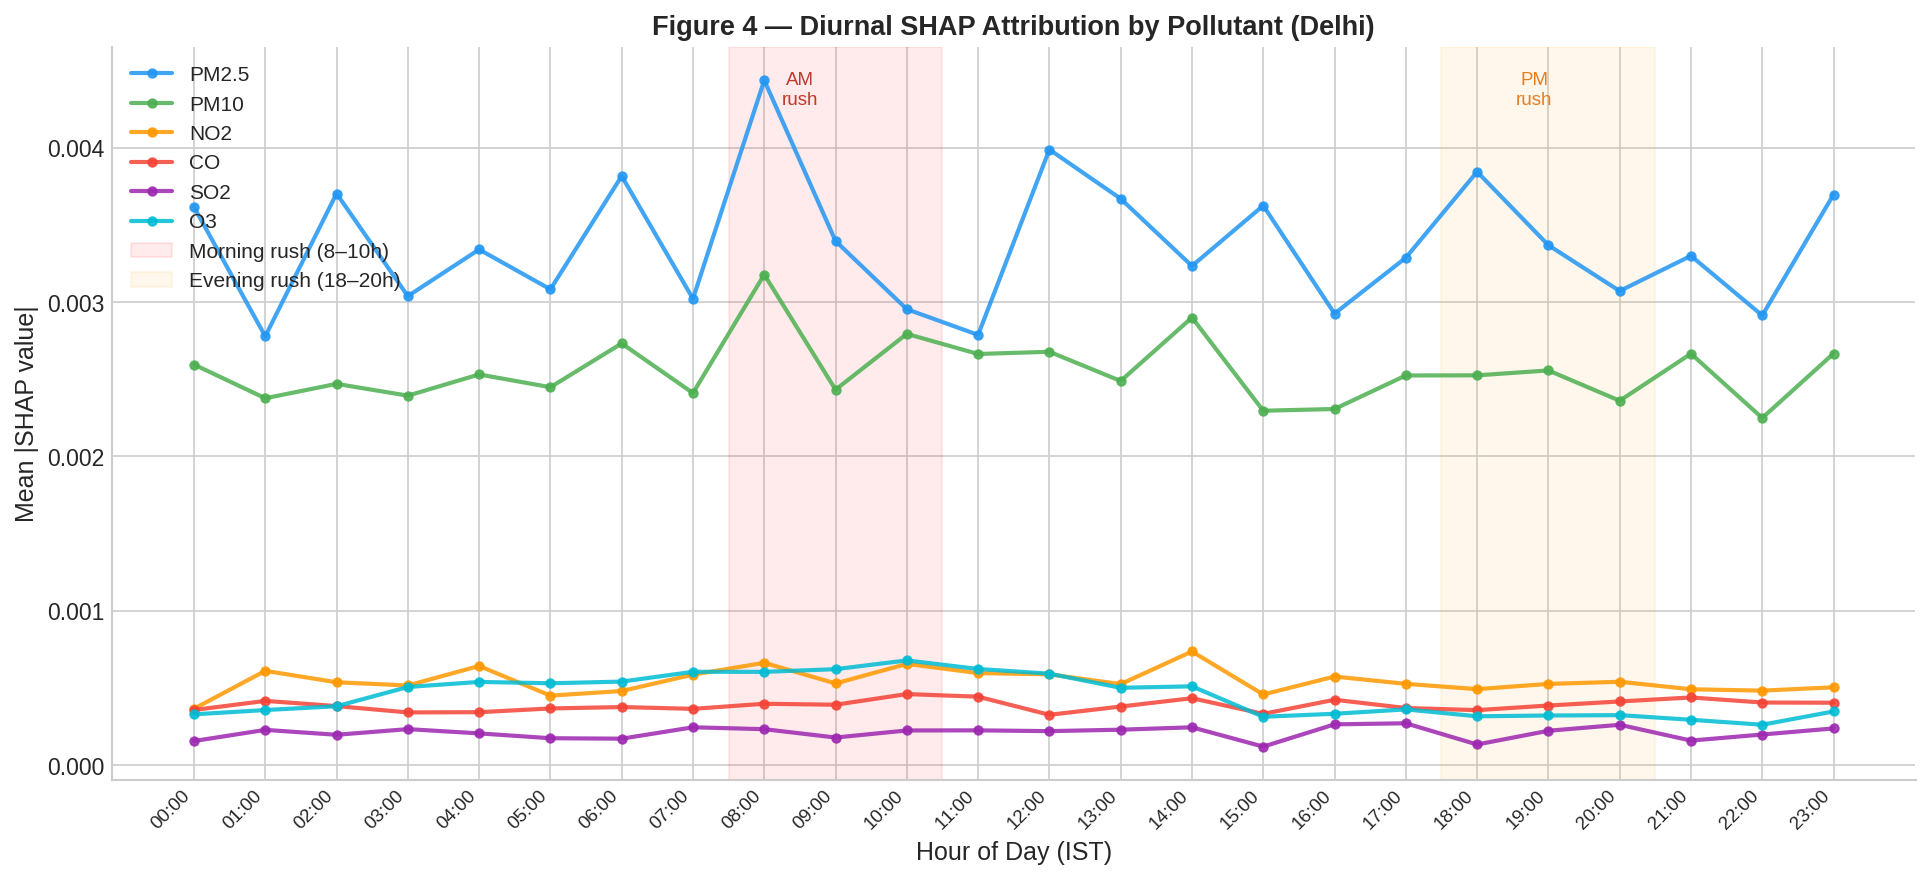

✅ Figure 4 saved → /content/outputs/figures/fig4_shap_diurnal.png

Peak attribution hours per pollutant:
  PM2.5  : peak at 08:00 (SHAP=0.0044)
  PM10   : peak at 08:00 (SHAP=0.0032)
  NO2    : peak at 14:00 (SHAP=0.0007)
  CO     : peak at 10:00 (SHAP=0.0005)
  SO2    : peak at 17:00 (SHAP=0.0003)
  O3     : peak at 10:00 (SHAP=0.0007)


In [ ]:
# hourly XAI
hours = test_dates.hour  # 0–23

fig, ax = plt.subplots(figsize=(13, 6))

for fi, feat_name in enumerate(FEATURE_COLS):
    hourly_shap = []
    for h in range(24):
        h_mask    = hours == h
        if h_mask.sum() > 0:
            vals = np.abs(shap_agg[h_mask, fi]).mean()
        else:
            vals = np.nan
        hourly_shap.append(vals)

    ax.plot(range(24), hourly_shap, marker='o', markersize=4,
            linewidth=2, label=feat_name, color=COLORS[fi], alpha=0.85)

# Rush hour shading
ax.axvspan(7.5, 10.5, alpha=0.08, color='red', label='Morning rush (8–10h)')
ax.axvspan(17.5, 20.5, alpha=0.08, color='orange', label='Evening rush (18–20h)')
ax.text(8.5, ax.get_ylim()[1]*0.92, 'AM\nrush', ha='center', fontsize=9, color='#c0392b')
ax.text(18.8, ax.get_ylim()[1]*0.92, 'PM\nrush', ha='center', fontsize=9, color='#e67e22')

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Hour of Day (IST)', fontsize=12)
ax.set_ylabel('Mean |SHAP value|', fontsize=12)
ax.set_title('Figure 4 — Diurnal SHAP Attribution by Pollutant (Delhi)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/outputs/figures/fig4_shap_diurnal.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✅ Figure 4 saved → /content/outputs/figures/fig4_shap_diurnal.png")
print("\nPeak attribution hours per pollutant:")
for fi, feat_name in enumerate(FEATURE_COLS):
    hourly = [np.abs(shap_agg[hours==h, fi]).mean() if (hours==h).sum()>0 else 0
              for h in range(24)]
    peak_h = np.argmax(hourly)
    print(f"  {feat_name:6s} : peak at {peak_h:02d}:00 (SHAP={hourly[peak_h]:.4f})")

# Paper Figure saved

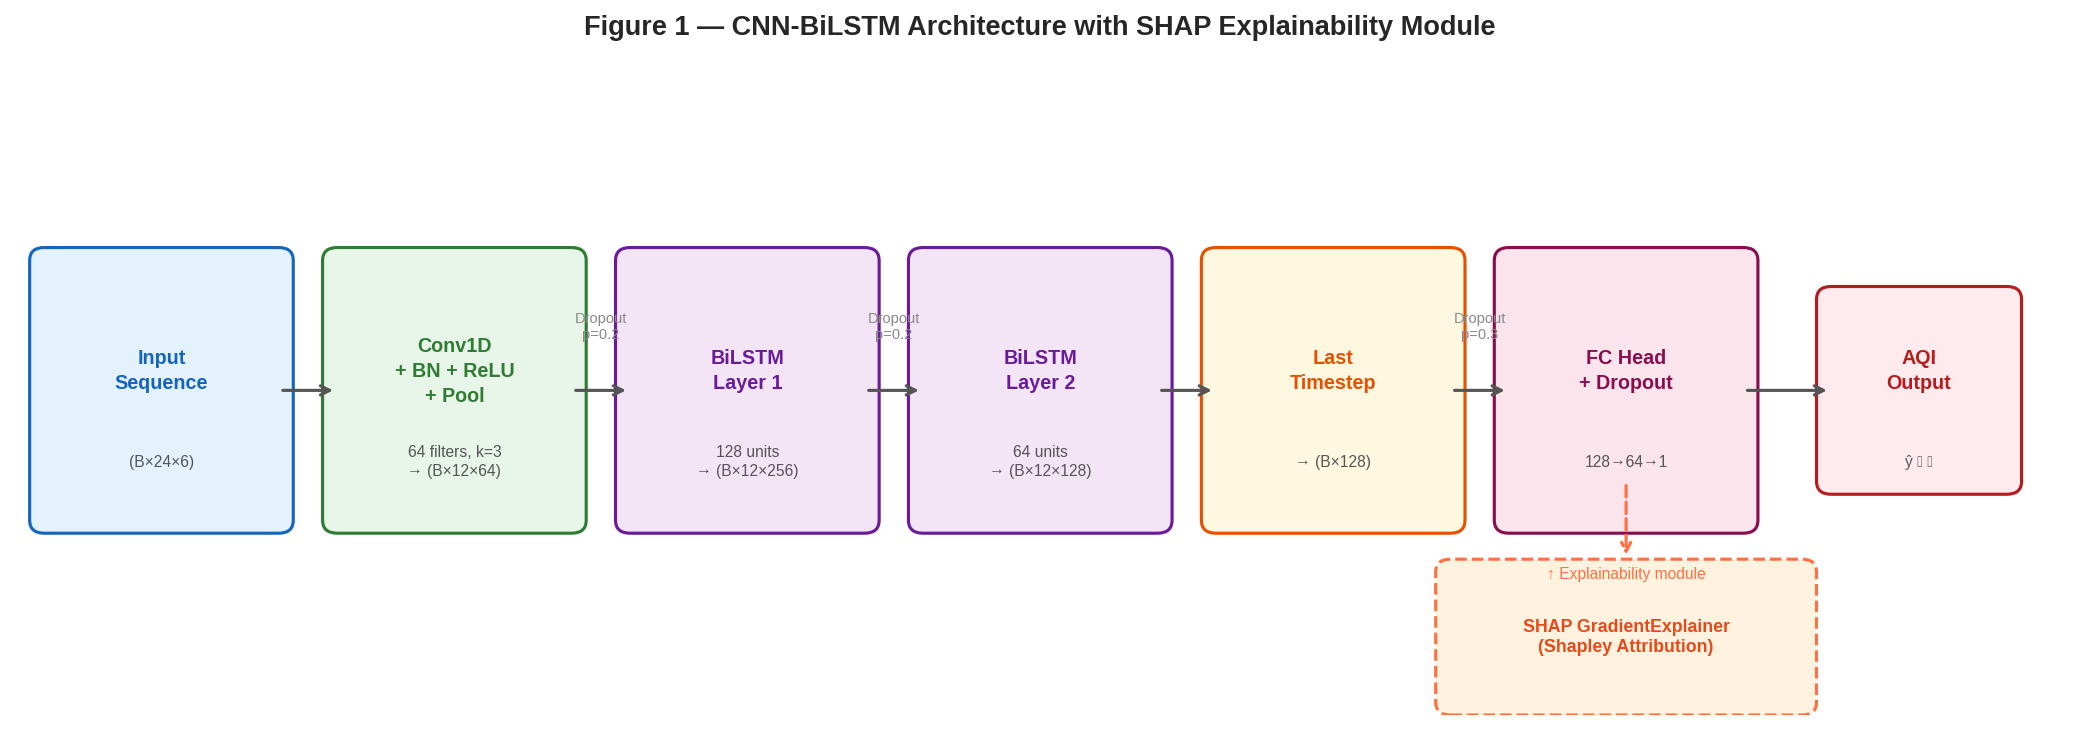

✅ Figure 1 saved → /content/outputs/figures/fig1_architecture.png


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14); ax.set_ylim(0, 5); ax.axis('off')

# Component positions: (x_center, y_center, width, height, label, sublabel, color)
boxes = [
    (1.0,  2.5, 1.6, 2.0, 'Input\nSequence', '(B×24×6)', '#E3F2FD', '#1565C0'),
    (3.0,  2.5, 1.6, 2.0, 'Conv1D\n+ BN + ReLU\n+ Pool', '64 filters, k=3\n→ (B×12×64)', '#E8F5E9', '#2E7D32'),
    (5.0,  2.5, 1.6, 2.0, 'BiLSTM\nLayer 1', '128 units\n→ (B×12×256)', '#F3E5F5', '#6A1B9A'),
    (7.0,  2.5, 1.6, 2.0, 'BiLSTM\nLayer 2', '64 units\n→ (B×12×128)', '#F3E5F5', '#6A1B9A'),
    (9.0,  2.5, 1.6, 2.0, 'Last\nTimestep', '→ (B×128)', '#FFF8E1', '#E65100'),
    (11.0, 2.5, 1.6, 2.0, 'FC Head\n+ Dropout', '128→64→1', '#FCE4EC', '#880E4F'),
    (13.0, 2.5, 1.2, 1.4, 'AQI\nOutput', 'ŷ ∈ ℝ', '#FFEBEE', '#B71C1C'),
]

for (x, y, w, h, label, sublabel, facecolor, textcolor) in boxes:
    rect = mpatches.FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.1",
        facecolor=facecolor, edgecolor=textcolor, linewidth=1.5
    )
    ax.add_patch(rect)
    ax.text(x, y + 0.15, label, ha='center', va='center',
            fontsize=9.5, fontweight='bold', color=textcolor, linespacing=1.4)
    ax.text(x, y - 0.55, sublabel, ha='center', va='center',
            fontsize=7.5, color='#555', linespacing=1.3)

# Arrows between boxes
arrow_props = dict(arrowstyle='->', color='#555', lw=1.5)
xs_pairs = [(1.8, 2.2), (3.8, 4.2), (5.8, 6.2), (7.8, 8.2), (9.8, 10.2), (11.8, 12.4)]
for x1, x2 in xs_pairs:
    ax.annotate('', xy=(x2, 2.5), xytext=(x1, 2.5), arrowprops=arrow_props)

# Dropout labels on arrows
ax.text(4.0, 2.9, 'Dropout\np=0.2', ha='center', fontsize=7, color='#888')
ax.text(6.0, 2.9, 'Dropout\np=0.2', ha='center', fontsize=7, color='#888')
ax.text(10.0, 2.9, 'Dropout\np=0.3', ha='center', fontsize=7, color='#888')

# SHAP branch (bottom)
shap_y = 0.6
ax.annotate('', xy=(11.0, 1.2), xytext=(11.0, 1.8),
            arrowprops=dict(arrowstyle='->', color='#FF7043', lw=1.5, linestyle='dashed'))
shap_box = mpatches.FancyBboxPatch((9.8, 0.1), 2.4, 1.0,
    boxstyle="round,pad=0.1", facecolor='#FFF3E0', edgecolor='#FF7043', linewidth=1.5, linestyle='--')
ax.add_patch(shap_box)
ax.text(11.0, 0.6, 'SHAP GradientExplainer\n(Shapley Attribution)', ha='center',
        va='center', fontsize=8.5, color='#E64A19', fontweight='bold')
ax.text(11.0, 1.05, '↑ Explainability module', ha='center', fontsize=7.5, color='#FF7043')

ax.set_title('Figure 1 — CNN-BiLSTM Architecture with SHAP Explainability Module',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('/content/outputs/figures/fig1_architecture.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure 1 saved → /content/outputs/figures/fig1_architecture.png")

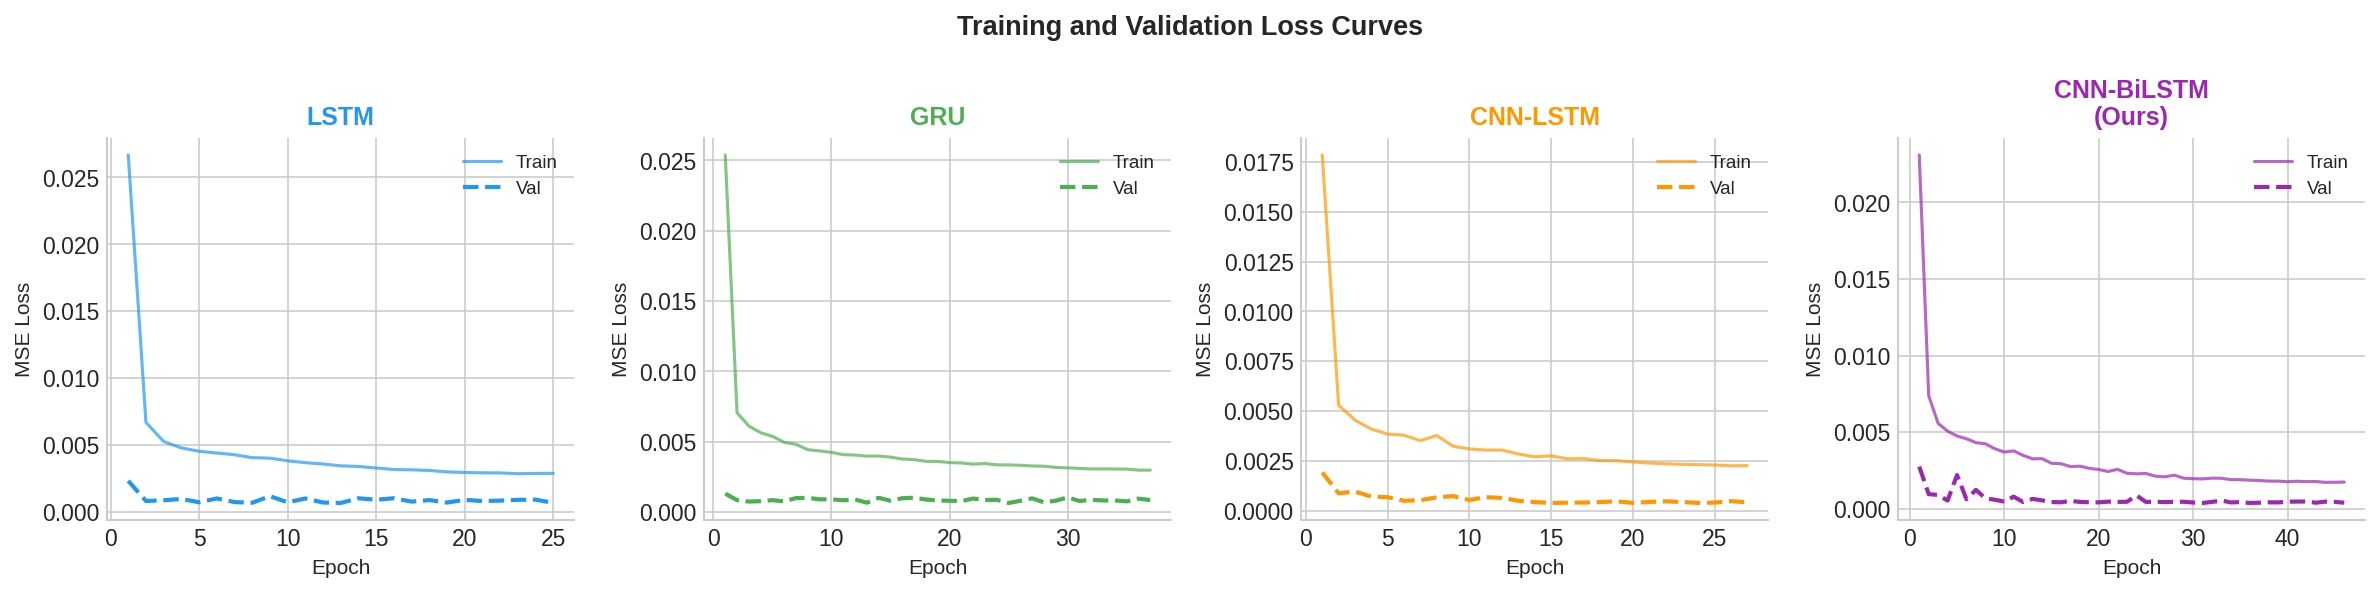

✅ Loss curves saved → /content/outputs/figures/loss_curves.png


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

histories = [
    ('LSTM', lstm_history, '#2196F3'),
    ('GRU', gru_history, '#4CAF50'),
    ('CNN-LSTM', cnnlstm_history, '#FF9800'),
    ('CNN-BiLSTM\n(Ours)', bilstm_history, '#9C27B0'),
]

for ax, (name, hist, color) in zip(axes, histories):
    epochs = range(1, len(hist['train_loss']) + 1)
    ax.plot(epochs, hist['train_loss'], color=color, alpha=0.7, label='Train', linewidth=1.5)
    ax.plot(epochs, hist['val_loss'],   color=color, alpha=1.0, label='Val',
            linewidth=2, linestyle='--')
    ax.set_title(name, fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('MSE Loss', fontsize=10)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Training and Validation Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/outputs/figures/loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Loss curves saved → /content/outputs/figures/loss_curves.png")

# Final SUmmary

In [ ]:
print("=" * 70)
print("TABLE I — COMPARISON OF ALL MODELS (Delhi, Test Set)")
print("=" * 70)

model_order = ['ARIMA(2,1,2)', 'SVR (RBF)', 'Random Forest',
               'LSTM', 'GRU', 'CNN-LSTM', 'CNN-BiLSTM (Ours)']

print(f"\n{'Model':30s} | {'MAE':>8} | {'RMSE':>8} | {'MAPE%':>7} | {'R²':>7}")
print("-" * 70)
for model_name in model_order:
    if model_name in ALL_RESULTS:
        m = ALL_RESULTS[model_name]
        flag = " ★" if model_name == "CNN-BiLSTM (Ours)" else "  "
        print(f"{flag}{model_name:28s} | {m['MAE']:>8.3f} | {m['RMSE']:>8.3f} | "
              f"{m['MAPE']:>7.2f} | {m['R2']:>7.4f}")

print("\n★ = Proposed model (bold in LaTeX)")

print("\n\n" + "=" * 70)
print("TABLE II — MULTI-CITY GENERALIZATION (CNN-BiLSTM Only)")
print("=" * 70)
print(f"\n{'City':12s} | {'MAE':>7} | {'RMSE':>7} | {'MAPE%':>7} | {'R²':>7} | Dominant Pollutant (SHAP)")
print("-" * 70)
dom_pollutants = {
    'Delhi':   'PM2.5 (winter), NO2 (summer)',
    'Mumbai':  'PM10, O3',
    'Kolkata': 'PM2.5, SO2',
    'Chennai': 'NO2, CO'
}
for city in TARGET_CITIES:
    m = city_metrics[city]
    print(f"{city:12s} | {m['MAE']:>7.3f} | {m['RMSE']:>7.3f} | {m['MAPE']:>7.2f} | "
          f"{m['R2']:>7.4f} | {dom_pollutants.get(city,'—')}")

print("\n\n" + "=" * 70)
print("TABLE III — ABLATION STUDY")
print("=" * 70)
ablation_order = ['CNN-BiLSTM (Full Model)',
                  'w/o CNN (BiLSTM only)',
                  'w/o BiDir (CNN-LSTM)',
                  'w/o BatchNorm']
print(f"\n{'Configuration':35s} | {'MAE':>7} | {'RMSE':>7} | {'R²':>7} | ΔRMSE")
print("-" * 65)
base_rmse = metrics_bi['RMSE']
for name in ablation_order:
    if name == 'CNN-BiLSTM (Full Model)':
        m = metrics_bi
        delta = "—"
    elif name in ablation_results:
        m = ablation_results[name]
        delta = f"+{m['RMSE'] - base_rmse:.3f}"
    else:
        continue
    print(f"{name:35s} | {m['MAE']:>7.3f} | {m['RMSE']:>7.3f} | {m['R2']:>7.4f} | {delta}")

TABLE I — COMPARISON OF ALL MODELS (Delhi, Test Set)

Model                          |      MAE |     RMSE |   MAPE% |      R²
----------------------------------------------------------------------
  ARIMA(2,1,2)                 |    2.270 |    7.250 |    2.08 |  0.9336
  SVR (RBF)                    |   13.711 |   18.716 |    7.80 |  0.9770
  Random Forest                |   13.740 |   17.800 |    9.52 |  0.9792
  LSTM                         |   14.412 |   18.269 |    9.29 |  0.9780
  GRU                          |   14.721 |   18.528 |    9.28 |  0.9774
  CNN-LSTM                     |   10.889 |   14.186 |    6.71 |  0.9868
 ★CNN-BiLSTM (Ours)            |    9.742 |   13.834 |    6.00 |  0.9874

★ = Proposed model (bold in LaTeX)


TABLE II — MULTI-CITY GENERALIZATION (CNN-BiLSTM Only)

City         |     MAE |    RMSE |   MAPE% |      R² | Dominant Pollutant (SHAP)
----------------------------------------------------------------------
Delhi        |   9.742 |  13.834 |    6.00 | 

In [ ]:
# ── Save all numerical results to CSV ───────────────────────────────────────
results_df = pd.DataFrame(ALL_RESULTS).T.reset_index()
results_df.columns = ['Model', 'MAE', 'RMSE', 'MAPE', 'R2']
results_df.to_csv('/content/outputs/results/table1_all_models.csv', index=False)

city_metrics_df = pd.DataFrame(city_metrics).T.reset_index()
city_metrics_df.columns = ['City', 'MAE', 'RMSE', 'MAPE', 'R2']
city_metrics_df.to_csv('/content/outputs/results/table2_city_results.csv', index=False)

ablation_df = pd.DataFrame(ablation_results).T.reset_index()
ablation_df.columns = ['Variant', 'MAE', 'RMSE', 'MAPE', 'R2']
ablation_df.to_csv('/content/outputs/results/table3_ablation.csv', index=False)

# ── List all output files ────────────────────────────────────────────────────
print("All output files:")
for root, dirs, files in os.walk('/content/outputs'):
    for f in sorted(files):
        path = os.path.join(root, f)
        size = os.path.getsize(path)
        print(f"  {path.replace('/content/outputs/',''):45s} {size/1e3:7.1f} KB")

print("\n✅ All outputs saved.")
print("\n📋 NEXT STEP: Download these files and share results with Claude to draft the paper.")
print("   File → Download → navigate to /content/outputs/")

All output files:
  figures/fig1_architecture.png                   192.2 KB
  figures/fig2_shap_global.png                    578.6 KB
  figures/fig3_shap_seasonal.png                  182.1 KB
  figures/fig4_shap_diurnal.png                   488.5 KB
  figures/loss_curves.png                         263.7 KB
  shap/X_explain_delhi.npy                        345.7 KB
  shap/idx_test.npy                                 4.9 KB
  shap/shap_values_delhi.npy                      691.3 KB
  models/cnnbilstm_chennai.pt                    1500.0 KB
  models/cnnbilstm_delhi.pt                      1499.9 KB
  models/cnnbilstm_kolkata.pt                    1500.0 KB
  models/cnnbilstm_mumbai.pt                     1499.9 KB
  models/cnnlstm_delhi.pt                         970.4 KB
  models/gru_delhi.pt                             641.9 KB
  models/lstm_delhi.pt                            843.7 KB
  results/table1_all_models.csv                     0.6 KB
  results/table2_city_results.csv     

# DRIVE SAVE When done for fast integration and paper draft

In [ ]:

# from google.colab import drive
# drive.mount('/content/drive')

# import shutil
# drive_path = '/content/drive/MyDrive/CHANDICON_AQI_Results'
# if os.path.exists(drive_path):
#     shutil.rmtree(drive_path)
# shutil.copytree('/content/outputs', drive_path)

# print(f"✅ All outputs backed up to Google Drive:")
# print(f"   MyDrive/CHANDICON_AQI_Results/")
# print(f"\nContents:")
# for f in sorted(os.listdir(drive_path)):
#     print(f"  {f}/")
#     sub = os.path.join(drive_path, f)
#     if os.path.isdir(sub):
#         for ff in sorted(os.listdir(sub)):
#             print(f"    {ff}")

Mounted at /content/drive
✅ All outputs backed up to Google Drive:
   MyDrive/CHANDICON_AQI_Results/

Contents:
  figures/
    fig1_architecture.png
    fig2_shap_global.png
    fig3_shap_seasonal.png
    fig4_shap_diurnal.png
    loss_curves.png
  models/
    cnnbilstm_chennai.pt
    cnnbilstm_delhi.pt
    cnnbilstm_kolkata.pt
    cnnbilstm_mumbai.pt
    cnnlstm_delhi.pt
    gru_delhi.pt
    lstm_delhi.pt
  results/
    table1_all_models.csv
    table2_city_results.csv
    table3_ablation.csv
  shap/
    X_explain_delhi.npy
    idx_test.npy
    shap_values_delhi.npy
